# Lab 1 DS & AI - DQ
# Influence of Data Quality on Machine Learning performance

_Don't forget to put your names and student numbers here_

**Authors**: 

In this lab we will explore different data quality problems and their possible effect on classification or regression tasks. To help you to start quickly with this lab, the notebook below already implements a basic Regression and Classification task. You can do the exercises by taking this code and modify/extend it. 

## Import Relevant Libraries

In [ ]:
# Uncomment if needed and restart the Kernel after installation
# %pip install seaborn

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.io import arff
import seaborn as sns
import pandas as pd
import warnings

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

warnings.filterwarnings("ignore", module="matplotlib\..*")


<>:14: SyntaxWarning: invalid escape sequence '\.'
<>:14: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_281828/4272800296.py:14: SyntaxWarning: invalid escape sequence '\.'
  warnings.filterwarnings("ignore", module="matplotlib\..*")


## Load Data
Some files are stored as an arff file, for which you can use the function below to load it into a pandas dataframe. An ARFF file can be viewed with a text editor; please do because it often contains documentation among other things about the meaning of the various attributes.

In [ ]:
def load_arff(file_path):
    '''Return a pandas dataframe and meta data from an arff file.'''
    ar, meta = arff.loadarff(file_path)
    return pd.DataFrame(ar), meta

# Classification
---
We will work with a credit approval dataset, where the goal is to classify whether a credit will be approved or not based on several input variables.

### Load the Data
Let's load in some data with which we will try to perform a classification on and print its meta data information to get a first overview.

In [ ]:

here = Path.cwd()
filelocation = here.parent / 'databank' / '00_raw' / 'uci-large'/ 'credit-a.arff'


# Load the arff file and print the meta information
data, meta = load_arff(filelocation)
print(meta)


Dataset: credit-rating
	A1's type is nominal, range is ('b', 'a')
	A2's type is numeric
	A3's type is numeric
	A4's type is nominal, range is ('u', 'y', 'l', 't')
	A5's type is nominal, range is ('g', 'p', 'gg')
	A6's type is nominal, range is ('c', 'd', 'cc', 'i', 'j', 'k', 'm', 'r', 'q', 'w', 'x', 'e', 'aa', 'ff')
	A7's type is nominal, range is ('v', 'h', 'bb', 'j', 'n', 'z', 'dd', 'ff', 'o')
	A8's type is numeric
	A9's type is nominal, range is ('t', 'f')
	A10's type is nominal, range is ('t', 'f')
	A11's type is numeric
	A12's type is nominal, range is ('t', 'f')
	A13's type is nominal, range is ('g', 'p', 's')
	A14's type is numeric
	A15's type is numeric
	class's type is nominal, range is ('+', '-')



## Data Preparation
Lets take a deeper look at the data and see if we can make some interesting observations.

In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      690 non-null    object 
 4   A5      690 non-null    object 
 5   A6      690 non-null    object 
 6   A7      690 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    float64
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    float64
 15  class   690 non-null    object 
dtypes: float64(6), object(10)
memory usage: 86.4+ KB


Here we can already observe that there exist some Null values in the table. Column `A2` and `A14` apparently have some null values (less non null values than the other columns). 
In this case we will deal with the null values by dropping them from the dataset.

In [ ]:
# remove all Nan values
data.dropna(inplace=True)

We will now take a look inside the data with the first 5 rows.

In [ ]:
data.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b'b',30.83,0.000,b'u',b'g',b'w',b'v',1.25,b't',b't',1.0,b'f',b'g',202.0,0.0,b'+'
1,b'a',58.67,4.460,b'u',b'g',b'q',b'h',3.04,b't',b't',6.0,b'f',b'g',43.0,560.0,b'+'
2,b'a',24.50,0.500,b'u',b'g',b'q',b'h',1.50,b't',b'f',0.0,b'f',b'g',280.0,824.0,b'+'
3,b'b',27.83,1.540,b'u',b'g',b'w',b'v',3.75,b't',b't',5.0,b't',b'g',100.0,3.0,b'+'
4,b'b',20.17,5.625,b'u',b'g',b'w',b'v',1.71,b't',b'f',0.0,b'f',b's',120.0,0.0,b'+'


We can observe that the nominal features are stored as an byte object (prefixed with a b like `b'a'`) . It is possible to convert the byte data type with the `decode()` function to strings.

In [ ]:
# save which columns are nominal
nominal = []

for col, typ in zip(data.columns, data.dtypes):
    if(typ == 'object'):
        # Decode the byte object for the whole column
        data[col] = data[col].map(lambda x: x.decode())
        # remember the nominal column for later
        nominal.append(col)
        
data.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1.0,f,g,202.0,0.0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6.0,f,g,43.0,560.0,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0.0,f,g,280.0,824.0,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5.0,t,g,100.0,3.0,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0.0,f,s,120.0,0.0,+


We will be working with a Naive Bayes classifier, but this ML method can only receive numerical data as its input. Therefore, we need to translate our nominal data to numeric. Because we have nominal data that does not have any ordering, we can apply **one hot encoding** to the nominal data. The pandas library contains the `get_dummies()` function that helps us to create these one hot encodings for nominal variables.

## Model Training: Classification
Now that we have looked at the data, it is time to define our regression tasks. We would like to predict the credit approval given our different input features. Therefore, our class label y will be the `'class'` column, which as we could see before encodes the approval binary as `+` or `-`.  

In [ ]:
data_original = data.copy()
features = data.columns.drop('class')

X = data[features]
y = data['class']


In [ ]:
def replace_by_noise(feat, noise_level=0.05, is_categorical=False, seed=0):
    noisy_feat = feat.copy()
    mask = np.random.random(size=len(feat), random_state=seed) < noise_level
    n_noisy = mask.sum()

    if is_categorical:
        categories = feat.dropna().unique()
        noise = np.random.choice(categories, size=n_noisy, random_state=seed)
    else:
        f_min, f_max = feat.min(), feat.max()
        noise = np.random.uniform(low=f_min, high=f_max, size=n_noisy, random_state=seed)

    noisy_feat.iloc[mask] = noise
    return noisy_feat


def build_data(X, y, feature_idx):
    noise_levels = [0.05 * i for i in range(20)]
    all_data = {}

    for noise_level in noise_levels:
        X_noisy = X.copy()
        
        feat_name = X.columns[feature_idx]
        is_cat = X[feat_name].dtype in ('object', 'str', 'string')
        
        X_noisy[feat_name] = replace_by_noise(
            X[feat_name], 
            noise_level=noise_level, 
            is_categorical=is_cat
        )
        
        X_encoded = pd.get_dummies(X_noisy)
        X_encoded = X_encoded.drop([col for col in X_encoded.columns if col.endswith('_?')], axis=1)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_encoded, y, train_size=0.7, test_size=0.3, random_state=100
        )

        all_data[noise_level] = (X_train, X_test, y_train, y_test)

    return all_data


def experiment(all_data):
    accuracies = {}
    
    for noise_level, (X_train, X_test, y_train, y_test) in all_data.items():
        classifier = GaussianNB()
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_test)

        accuracies[noise_level] = accuracy_score(y_test, y_pred)

    return accuracies


In [ ]:
import matplotlib.pyplot as plt


def plot_noise_vs_accuracy(accuracies, feat_name="Feature"):
    noise_levels = list(accuracies.keys())
    acc_values = list(accuracies.values())

    acc_min, acc_max = min(acc_values), max(acc_values)

    plt.figure(figsize=(8, 5))
    plt.plot(
        noise_levels,
        acc_values,
        marker="o",
        linewidth=2,
        markersize=6,
        color="#1f77b4",
    )

    plt.title(
        f"Impact of Noise on GaussianNB Accuracy ({feat_name})", fontsize=13
    )
    plt.xlabel("Noise Level (Proportion Replaced)", fontsize=11)
    plt.ylabel("Accuracy", fontsize=11)
    plt.ylim(acc_min-0.05, acc_max+0.05)
    plt.grid(True, linestyle="--", alpha=0.6)
 
    plt.gca().xaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{int(y*100)}%")
    )

    plt.tight_layout()
    plt.show()



In [ ]:
data_baseline = data_original.copy()
y_baseline = data_baseline['class']
X_baseline = data_baseline.drop('class', axis=1)

X_baseline_encoded = pd.get_dummies(X_baseline)
X_baseline_encoded = X_baseline_encoded.drop([col for col in X_baseline_encoded.columns if col.endswith('_?')], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_baseline_encoded, y_baseline, train_size=0.7, test_size=0.3, random_state=100
)

classifier = GaussianNB(random_state=100)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy (0% noise): {baseline_accuracy:.4f}")


Baseline Accuracy (0% noise): 0.8250



--- ## Single Feature Experiment ---
Corrupting feature: A1 (categorical)
Baseline accuracy: 0.8250



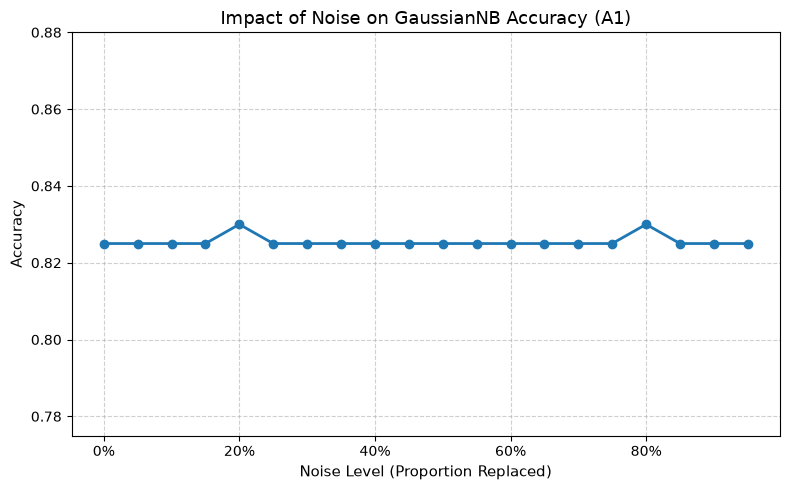

In [ ]:
chosen_feature_id = 0
chosen_feature_name = features[chosen_feature_id]

is_cat = data_original[chosen_feature_name].dtype in ('object', 'str', 'string')

print(f"\n--- ## Single Feature Experiment ---")
print(f"Corrupting feature: {chosen_feature_name} ({'categorical' if is_cat else 'numerical'})")
print(f"Baseline accuracy: {baseline_accuracy:.4f}\n")

all_data = build_data(X, y, chosen_feature_id)
accuracies = experiment(all_data)

plot_noise_vs_accuracy(accuracies, feat_name=chosen_feature_name)


Processing feature 1/15: A1
Processing feature 2/15: A2
Processing feature 3/15: A3
Processing feature 4/15: A4
Processing feature 5/15: A5
Processing feature 6/15: A6
Processing feature 7/15: A7
Processing feature 8/15: A8
Processing feature 9/15: A9
Processing feature 10/15: A10
Processing feature 11/15: A11
Processing feature 12/15: A12
Processing feature 13/15: A13
Processing feature 14/15: A14
Processing feature 15/15: A15


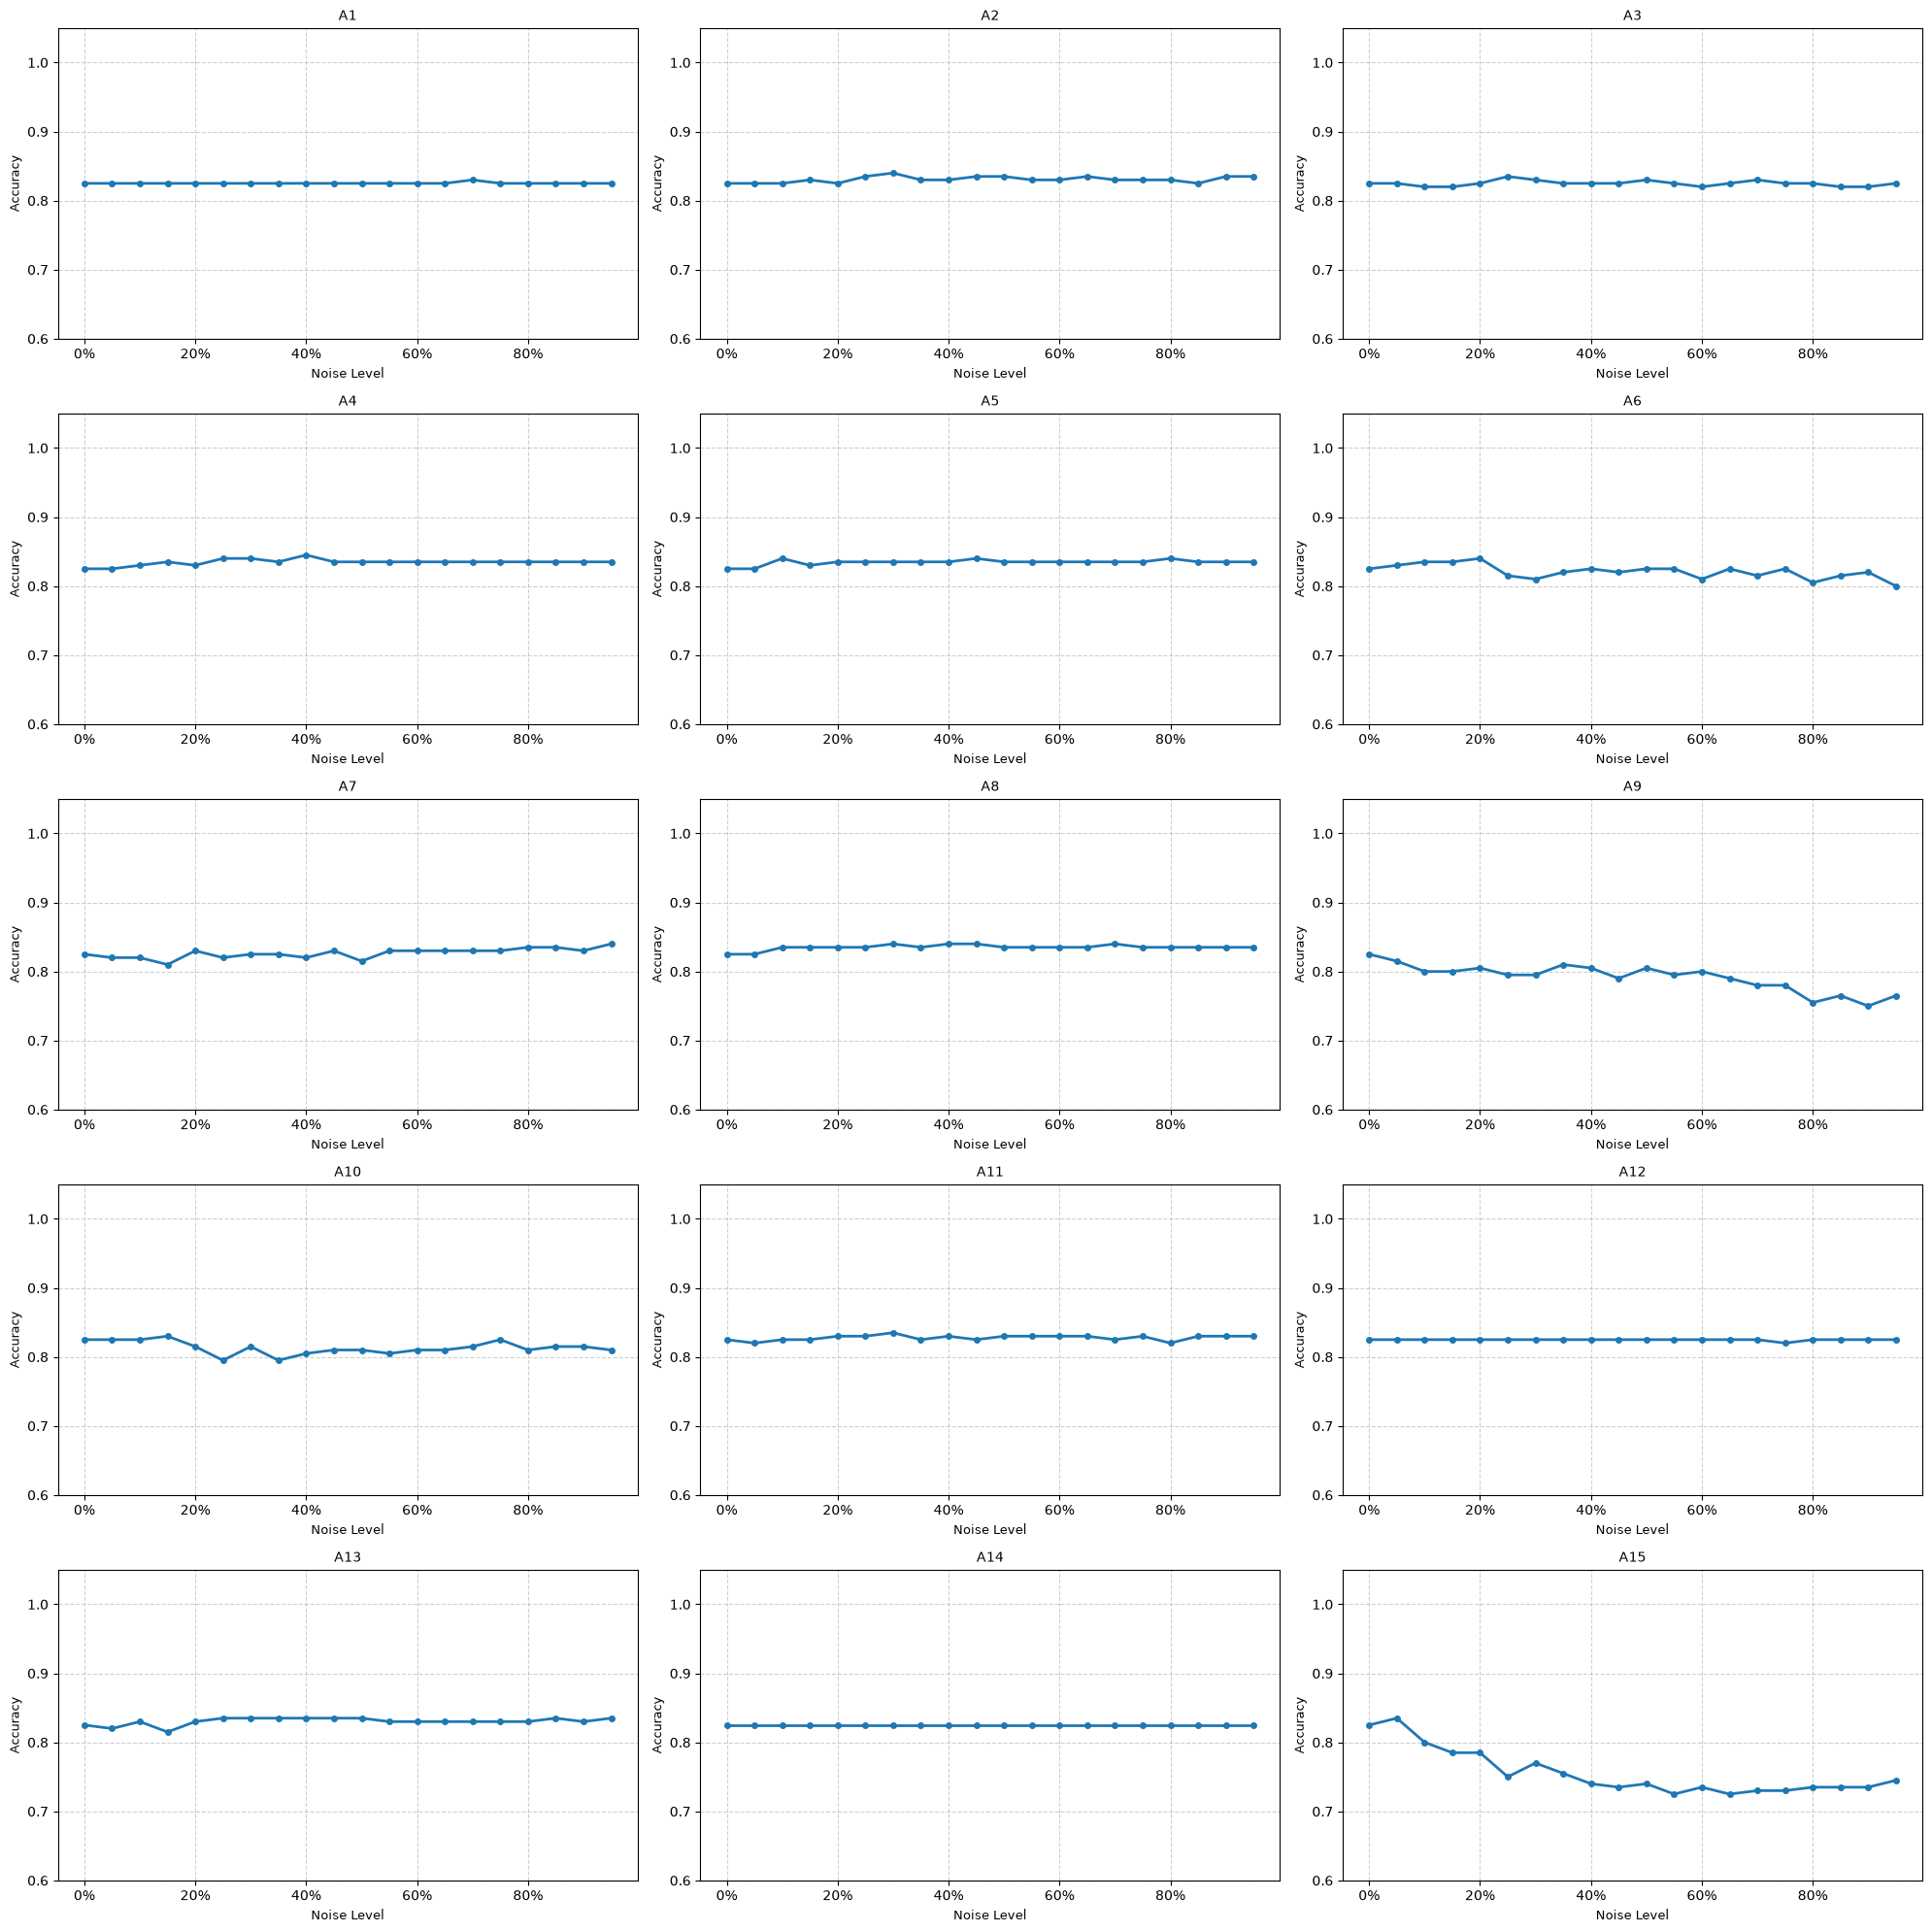

In [ ]:
num_features = len(features)
cols = 3
rows = (num_features + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for featid, feat_name in enumerate(features):
    print(f"Processing feature {featid + 1}/{num_features}: {feat_name}")
    
    all_data = build_data(X, y, featid)
    accuracies = experiment(all_data)
    
    noise_levels = list(accuracies.keys())
    acc_values = list(accuracies.values())
    
    ax = axes[featid]
    ax.plot(
        noise_levels,
        acc_values,
        marker="o",
        linewidth=2,
        markersize=4,
        color="#1f77b4",
    )
    ax.set_title(f"{feat_name}", fontsize=10)
    ax.set_xlabel("Noise Level", fontsize=9)
    ax.set_ylabel("Accuracy", fontsize=9)
    ax.set_ylim(0.6, 1.05)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{int(y*100)}%")
    )

for idx in range(num_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


# Takeaway

experiment on feature A2 suggest that 